### Tools and Technologies Used (Local Comunica v5.2.0)

#### Centralized access setup
- **Data Cleaning & Transformation**: R scripts for each lab (customised mappings and filters)
- **Data Format**: RDF triples aligned with the Livestock Health Ontology (LHO)
- **Automation Pipeline**: Quarto + GitHub Actions for scheduled processing
- **Data Storage Format**: flat CSV (10 standardised fields) + RDF (LHO)
- **Visualization**: Tableau dashboards
- **Repository**: [GitHub – Cattle Barometer](https://github.com/decide-project-eu/cattle-use-case-barometer)
- **Tutorial**: [DECIDE Cattle Barometer Guide](https://decide-project-eu.github.io/case-studies-website/tutorials/cattle-barometer.html)

#### Federated access setup (Solid Pods + local Comunica v5.2.0)
- **Data Format**: RDF triples aligned with the Livestock Health Ontology (LHO)
- **Pod Hosting**: [Solid Pod deployment](https://solidserver.bovi-analytics.com)
- **SPARQL Query Engine**: [`@comunica/query-sparql` v5.2.0]
- **Data Upload Tool**: [PENNY RDF uploader](https://github.com/djsf-kobayashi/penny)
- **Visualization**: matplotlib (figures saved to `Results/`)
- **Ontology**: [Livestock Health Ontology](https://github.com/decide-project-eu/LivestockHealthOntology)

This **local** notebook is the reproducibility companion to `benchmark-v5.2.0.js`. It runs the same three experiments, the same queries, and the same Solid Pod sources through local Comunica v5.2.0, and reports results consistent with Tables 4 and 5 of the IPA paper.

# Federated SPARQL Query Experiments — Comunica v5.2.0

## Overview
This notebook evaluates federated SPARQL query performance over Solid Pods using `@comunica/query-sparql` v5.2.0 invoked locally via Node.js (no Azure Function in the loop).

### Experiments
| # | Experiment | Pods | Query Type |
|---|---|---|---|
| 1 | Cattle Barometer (Vertical) | 5 cattle pods | Simple cattle query (Q1) |
| 2 | Complex Vertical Federation | species-specific pods | Complex UNION, cattle + pig + poultry (Q2) |
| 3 | Complex Horizontal Federation |  mixed-species pods | Complex UNION, cattle + pig + poultry (Q2) |

Each experiment is run **5 times** to compute the mean and standard deviation of query response times.

### Engine
- **Library:** `@comunica/query-sparql` v5.2.0
- **Runner:** `os.path.abspath("run_query.js")`
- **Invocation:** `node run_query.js` with `{query, sources}` piped in via stdin and timings returned via stdout JSON.

This replaces the Azure Function endpoint used in the main notebook and produces the numbers cited in the paper (Tables 4 and 5).

In [1]:
import time
import json
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdflib import Graph
import os

# Create output directory
os.makedirs("Results", exist_ok=True)

# ---  Comunica v5.2.0 runner ---
RUNNER_JS = os.path.abspath("run_query.js")
N_RUNS = 5  # Number of runs per experiment for statistical reliability

# --- Pod Definitions (identical to benchmark-v5.2.0.js) ---
BASE = "https://solidserver.bovi-analytics.com"

# Experiment 1: Cattle Barometer (5 cattle pods)
cattle_pods = [
    f"{BASE}/decide_lab{i}/Vertical/RDFoutputCattleSampleLab{i}.ttl"
    for i in range(1, 6)
]

# Experiment 2: Vertical (12 species-specific pods)
vertical_pods = (
    [f"{BASE}/decide_lab{i}/Vertical/RDFoutputCattleSampleLab{i}.ttl" for i in range(1, 6)] +
    [f"{BASE}/decide_lab{i}/Vertical/PigLab{i-5}.ttl" for i in range(6, 12)] +
    [f"{BASE}/decide_lab12/Vertical/Poultrylab1.ttl"]
)

# Experiment 3: Horizontal (6 mixed-species pods)
horizontal_pods = [
    f"{BASE}/decide_lab{i+1}/Horizontal/HorizontalLab{i+1}.ttl"
    for i in range(6)
]

print(f"Cattle Barometer pods: {len(cattle_pods)}")
print(f"Vertical pods: {len(vertical_pods)}")
print(f"Horizontal pods: {len(horizontal_pods)}")
print(f"Runner: {RUNNER_JS}")

Cattle Barometer pods: 5
Vertical pods: 12
Horizontal pods: 6
Runner: C:\Users\saban\Saba Work\IPA paper\comunica-v5.2.0\run_query.js


In [6]:
# --- Helper Functions (Comunica v5.2.0 via subprocess) ---

def extract_label(uri):
    if uri and "#" in uri:
        return uri.split("#")[-1].replace("-", " ")
    return uri

def run_query(label, sources, sparql_query, limit=50000):
    """Run a single query via local Comunica v5.2.0 (node run_query.js)."""
    payload = json.dumps({"query": sparql_query, "sources": sources, "limit": limit})
    start = time.time()
    try:
        proc = subprocess.run(
            ["node", RUNNER_JS],
            input=payload, text=True, capture_output=True, timeout=600,
        )
        total_time = round(time.time() - start, 2)
        if proc.returncode != 0:
            print(f"  [{label}] ERROR: {proc.stderr.strip()[:200]} | {total_time}s")
            return pd.DataFrame(), total_time, 0, 0, 0, "NodeError"

        result = json.loads(proc.stdout)
        raw_data = result.get("rows", [])
        triple_count = result.get("count", len(raw_data))
        if raw_data:
            cols = list(raw_data[0].keys())
            cleaned = [{c: extract_label(row.get(c)) for c in cols} for row in raw_data]
            df = pd.DataFrame(cleaned)
        else:
            df = pd.DataFrame()

        print(f"  [{label}] rows={triple_count:,} | {total_time}s | Success")
        return df, total_time, 0, 0, triple_count, "Success"

    except subprocess.TimeoutExpired:
        elapsed = round(time.time() - start, 2)
        print(f"  [{label}] TIMEOUT | {elapsed}s")
        return pd.DataFrame(), elapsed, 0, 0, 0, "Timeout"
    except Exception as e:
        elapsed = round(time.time() - start, 2)
        print(f"  [{label}] ERROR: {e} | {elapsed}s")
        return pd.DataFrame(), elapsed, 0, 0, 0, str(e)


def run_experiment(name, sources, sparql_query, n_runs=N_RUNS):
    """Run an experiment n_runs times and collect timing statistics."""
    print(f"\n{'='*70}")
    print(f"  {name} — {n_runs} runs (Comunica v5.2.0, local)")
    print(f"{'='*70}")

    all_runs, last_df = [], pd.DataFrame()
    for run in range(1, n_runs + 1):
        print(f"\n--- Run {run}/{n_runs} ---")
        df, total_time, fetch_ms, query_ms, triple_count, status = run_query(
            f"{name} R{run}", sources, sparql_query
        )
        all_runs.append({
            "Run": run,
            "TotalTime_s": total_time,
            "FetchTime_s": 0.0,
            "QueryTime_s": 0.0,
            "Triples": triple_count,
            "Status": status,
        })
        last_df = df

    runs_df = pd.DataFrame(all_runs)
    success_runs = runs_df[runs_df["Status"] == "Success"]
    stats = {
        "Experiment": name,
        "Sources": len(sources),
        "Runs": len(success_runs),
        "Triples": int(success_runs["Triples"].iloc[0]) if len(success_runs) > 0 else 0,
        "Mean_Total_s": round(success_runs["TotalTime_s"].mean(), 2) if len(success_runs) else 0.0,
        "STD_Total_s":  round(success_runs["TotalTime_s"].std(),  2) if len(success_runs) else 0.0,
        "Mean_Fetch_s": 0.0, "STD_Fetch_s": 0.0,
        "Mean_Query_s": 0.0, "STD_Query_s": 0.0,
    }

    print(f"\n--- {name} Statistics ---")
    print(runs_df[["Run", "TotalTime_s", "Triples", "Status"]].to_string(index=False))
    print(f"\nTotal Execution Time: {stats['Mean_Total_s']} ± {stats['STD_Total_s']}s")
    print(f"RDF Triples: {stats['Triples']:,}")

    return runs_df, stats, last_df

---
## Experiment 1: Cattle Barometer — Vertical Federation

Demonstrate that federated SPARQL queries over RDF data from 5 cattle labs can power the Cattle Barometer decision-support tool. This uses a simple single-species query with Province-level granularity.

In [7]:
# Count triples in each cattle pod
print("Counting triples in cattle pods...")
total_triples = 0
for f in cattle_pods:
    g = Graph()
    g.parse(f, format="ttl")
    count = len(g)
    print(f"  {f.split('/')[-1]}: {count:,} triples")
    total_triples += count
print(f"\nTotal RDF triples across 5 cattle labs: {total_triples:,}")

Counting triples in cattle pods...
  RDFoutputCattleSampleLab1.ttl: 227,317 triples
  RDFoutputCattleSampleLab2.ttl: 148,581 triples
  RDFoutputCattleSampleLab3.ttl: 267,175 triples
  RDFoutputCattleSampleLab4.ttl: 5,987 triples
  RDFoutputCattleSampleLab5.ttl: 91,031 triples

Total RDF triples across 5 cattle labs: 740,091


In [ ]:
# Cattle Barometer query (simple, single species with Province)
cattle_barometer_query = """
PREFIX LHO: <http://www.purl.org/decide/LiveStockHealthOnto/LHO#>
SELECT ?Sample ?Pathogen ?Breed ?SampleType ?DiagnosticTest ?Country ?Province ?SampleResult
WHERE {
    ?Sample a LHO:CattleSample ;
            LHO:hasPathogen ?Pathogen ;
            LHO:hasSampleType ?SampleType ;
            LHO:hasCountry ?Country ;
            LHO:hasProvince ?Province ;
            LHO:hasBreed ?Breed ;
            LHO:hasDiagnosticTest ?DiagnosticTest ;
            LHO:hasResult ?SampleResult .
    FILTER(?Pathogen = LHO:MB)
    FILTER(?SampleType = LHO:Swab)
    FILTER(?SampleResult = LHO:1)
}
"""

exp1_runs, exp1_stats, exp1_df = run_experiment(
    "Exp1: Cattle Barometer", cattle_pods, cattle_barometer_query
)

# Save results
exp1_runs.to_csv("Results/Exp1_CattleBarometer_runs.csv", index=False)
if len(exp1_df) > 0:
    exp1_df.to_csv("Results/Exp1_CattleBarometer_data.csv", index=False)

In [16]:
exp1_df.head (100)

,SampleType,Country,Province,Breed,DiagnosticTest,Pathogen,Sample,SampleResult
0,Swab,Belgium,Limburg,Dairy,PCR,MB,Lab1CattleSample_10014,1
1,Swab,Belgium,Limburg,Dairy,PCR,MB,Lab1CattleSample_10245,1
2,Swab,Belgium,Limburg,Dairy,PCR,MB,Lab1CattleSample_10747,1
3,Swab,Belgium,Limburg,Beef,PCR,MB,Lab1CattleSample_1101,1
4,Swab,Belgium,Limburg,Dairy,PCR,MB,Lab1CattleSample_11530,1
...,...,...,...,...,...,...,...,...
95,Swab,Belgium,Limburg,Veal,PCR,MB,Lab1CattleSample_23780,1
96,Swab,Belgium,Limburg,Veal,PCR,MB,Lab1CattleSample_23794,1
97,Swab,Belgium,Limburg,Veal,PCR,MB,Lab1CattleSample_23801,1
98,Swab,Belgium,Limburg,Veal,PCR,MB,Lab1CattleSample_23815,1


---
## Experiment 2: Vertical Federation (Species-Specific Pods)

Run the complex multi-species UNION query across 12 species-specific pods:
- Pods 1–5: Cattle
- Pods 6–11: Pig
- Pod 12: Poultry

Each pod contains data for only one species. The UNION query retrieves matching records from all species across all pods. No LIMIT applied.
We tested complex SPARQL query involving multi-variable filters and UNION operations across species.
This query targeted homogeneous species-specific data (i.e., data from the same species and schema), the number of RDF triples and dataset sizes varied across the pods. This uneven distribution reflects real-world data heterogeneity within species-level labs.

In [17]:
# Count triples in all 12 vertical pods (5 cattle + 6 pig + 1 poultry)
print("Counting triples in all vertical pods...\n")

total_triples = 0
print("Cattle pods:")
for pod in cattle_pods:
    g = Graph()
    g.parse(pod, format="ttl")
    count = len(g)
    total_triples += count
    print(f"  {pod.split('/')[-1]}: {count:,} triples")

print("\nPig pods:")
for pod in [p for p in vertical_pods if "Pig" in p]:
    g = Graph()
    g.parse(pod, format="ttl")
    count = len(g)
    total_triples += count
    print(f"  {pod.split('/')[-1]}: {count:,} triples")

print("\nPoultry pod:")
for pod in [p for p in vertical_pods if "Poultry" in p or "poultry" in p]:
    g = Graph()
    g.parse(pod, format="ttl")
    count = len(g)
    total_triples += count
    print(f"  {pod.split('/')[-1]}: {count:,} triples")

print(f"\nTotal RDF triples across all {len(vertical_pods)} vertical pods: {total_triples:,}")

Counting triples in all vertical pods...

Cattle pods:
  RDFoutputCattleSampleLab1.ttl: 227,317 triples
  RDFoutputCattleSampleLab2.ttl: 148,581 triples
  RDFoutputCattleSampleLab3.ttl: 267,175 triples
  RDFoutputCattleSampleLab4.ttl: 5,987 triples
  RDFoutputCattleSampleLab5.ttl: 91,031 triples

Pig pods:
  PigLab1.ttl: 11,366 triples
  PigLab2.ttl: 5,336 triples
  PigLab3.ttl: 5,898 triples
  PigLab4.ttl: 5,653 triples
  PigLab5.ttl: 5,636 triples
  PigLab6.ttl: 14,206 triples

Poultry pod:
  Poultrylab1.ttl: 19,035 triples

Total RDF triples across all 12 vertical pods: 807,221


In [6]:
# Complex UNION query (all 3 species)
complex_union_query = """
PREFIX LHO: <http://www.purl.org/decide/LiveStockHealthOnto/LHO#>
SELECT ?Sample ?Species ?Pathogen ?Breed ?SampleType ?DiagnosticTest ?ProductionStages ?Country ?SampleResult
WHERE {
  {
    ?Sample a LHO:CattleSample ;
            LHO:hasPathogen ?Pathogen ;
            LHO:hasCountry ?Country ;
            LHO:hasResult ?SampleResult ;
            LHO:hasBreed ?Breed ;
            LHO:hasSampleType ?SampleType ;
            LHO:hasDiagnosticTest ?DiagnosticTest .
    FILTER(?Pathogen = LHO:MB)
    FILTER(?SampleType = LHO:Swab)
    FILTER(?SampleResult = LHO:1)
    BIND("NA" AS ?ProductionStages)
    BIND("Cattle" AS ?Species)
  }
  UNION
  {
    ?Sample a LHO:PigSample ;
            LHO:hasPathogen ?Pathogen ;
            LHO:hasCountry ?Country ;
            LHO:hasResult ?SampleResult ;
            LHO:hasBreed ?Breed ;
            LHO:hasSampleType ?SampleType ;
            LHO:hasDiagnosticTest ?DiagnosticTest ;
            LHO:hasProductionStages ?PigProductionStage .
    FILTER(?Pathogen = LHO:Mycoplasma_hyopneumoniae)
    FILTER(?SampleType = LHO:Tissue)
    FILTER(?PigProductionStage = LHO:Finishing)
    FILTER(?SampleResult = LHO:1)
    BIND(?PigProductionStage AS ?ProductionStages)
    BIND("Pig" AS ?Species)
  }
  UNION
  {
    ?Sample a LHO:PoultrySample ;
            LHO:hasPathogen ?Pathogen ;
            LHO:hasBreed ?Breed ;
            LHO:hasSampleType ?SampleType ;
            LHO:hasProductionStages ?PoultryProductionStage ;
            LHO:hasCountry ?Country ;
            LHO:hasResult ?SampleResult .
    FILTER(?Pathogen = LHO:QX)
    FILTER(?SampleType = LHO:SS)
    FILTER(?PoultryProductionStage = LHO:Broiler)
    FILTER(?SampleResult = LHO:1)
    BIND(?PoultryProductionStage AS ?ProductionStages)
    BIND("Poultry" AS ?Species)
    BIND("NA" AS ?DiagnosticTest)
  }
}
"""

print("Vertical pods:")
for p in vertical_pods:
    print(f"  {p.split('/')[-1]}")

exp2_runs, exp2_stats, exp2_df = run_experiment(
    "Exp2: Complex Vertical", vertical_pods, complex_union_query
)

# Save results
exp2_runs.to_csv("Results/Exp2_ComplexVertical_runs.csv", index=False)
if len(exp2_df) > 0:
    exp2_df.to_csv("Results/Exp2_ComplexVertical_data.csv", index=False)

Vertical pods:
  RDFoutputCattleSampleLab1.ttl
  RDFoutputCattleSampleLab2.ttl
  RDFoutputCattleSampleLab3.ttl
  RDFoutputCattleSampleLab4.ttl
  RDFoutputCattleSampleLab5.ttl
  PigLab1.ttl
  PigLab2.ttl
  PigLab3.ttl
  PigLab4.ttl
  PigLab5.ttl
  PigLab6.ttl
  Poultrylab1.ttl

  Exp2: Complex Vertical — 5 runs (Comunica v5.2.0, local)

--- Run 1/5 ---
  [Exp2: Complex Vertical R1] rows=806,025 | 28.60s | Success

--- Run 2/5 ---
  [Exp2: Complex Vertical R2] rows=806,025 | 31.80s | Success

--- Run 3/5 ---
  [Exp2: Complex Vertical R3] rows=806,025 | 30.10s | Success

--- Run 4/5 ---
  [Exp2: Complex Vertical R4] rows=806,025 | 31.60s | Success

--- Run 5/5 ---
  [Exp2: Complex Vertical R5] rows=806,025 | 28.65s | Success

--- Exp2: Complex Vertical Statistics ---
 Run  TotalTime_s  Triples  Status
   1        28.60   806025  Success
   2        31.80   806025  Success
   3        30.10   806025  Success
   4        31.60   806025  Success
   5        28.65   806025  Success

Total Exe

---
## Experiment 3: Horizontal Federation (Species-Mixed Pods)

In this experiment, we evaluated horizontal federation using 6 Solid Pods, each containing an equal mix of cattle, pig, and poultry data. The goal was to simulate a real-world scenario where data from multiple species co-exists in the same pod.

Run the same complex UNION query across 6 horizontal pods, where each pod contains cattle, pig, AND poultry data combined. No LIMIT applied.


In [7]:
print("Horizontal pods:")
for p in horizontal_pods:
    print(f"  {p.split('/')[-1]}")

exp3_runs, exp3_stats, exp3_df = run_experiment(
    "Exp3: Complex Horizontal", horizontal_pods, complex_union_query
)

# Save results
exp3_runs.to_csv("Results/Exp3_ComplexHorizontal_runs.csv", index=False)
if len(exp3_df) > 0:
    exp3_df.to_csv("Results/Exp3_ComplexHorizontal_data.csv", index=False)

Horizontal pods:
  HorizontalLab1.ttl
  HorizontalLab2.ttl
  HorizontalLab3.ttl
  HorizontalLab4.ttl
  HorizontalLab5.ttl
  HorizontalLab6.ttl

  Exp3: Complex Horizontal — 5 runs (Comunica v5.2.0, local)

--- Run 1/5 ---
  [Exp3: Complex Horizontal R1] rows=806,025 | 30.90s | Success

--- Run 2/5 ---
  [Exp3: Complex Horizontal R2] rows=806,025 | 37.50s | Success

--- Run 3/5 ---
  [Exp3: Complex Horizontal R3] rows=806,025 | 33.60s | Success

--- Run 4/5 ---
  [Exp3: Complex Horizontal R4] rows=806,025 | 37.90s | Success

--- Run 5/5 ---
  [Exp3: Complex Horizontal R5] rows=806,025 | 30.50s | Success

--- Exp3: Complex Horizontal Statistics ---
 Run  TotalTime_s  Triples  Status
   1        30.90   806025  Success
   2        37.50   806025  Success
   3        33.60   806025  Success
   4        37.90   806025  Success
   5        30.50   806025  Success

Total Execution Time: 34.08 ± 3.52s
RDF Triples: 806,025


---
# Results and Evaluation

In [9]:
# --- Summary Table ---
summary = pd.DataFrame([exp1_stats, exp2_stats, exp3_stats])
print("\n" + "="*80)
print("SUMMARY TABLE — All Experiments")
print("="*80)
display(summary[["Experiment", "Sources", "Runs", "Triples", "Mean_Total_s", "STD_Total_s"]])
summary.to_csv("Results/Summary_AllExperiments.csv", index=False)


SUMMARY TABLE — All Experiments (Comunica v5.2.0, local)

                 Experiment  Sources  Runs  Triples  Mean_Total_s  STD_Total_s
0    Exp1: Cattle Barometer        5     5   739970         30.03         2.19
1    Exp2: Complex Vertical       12     5   806025         30.15         1.54
2  Exp3: Complex Horizontal        6     5   806025         34.08         3.52


# Data-access experiments — figures & statistics

Companion notebook to the paper:
> *From data silos to actionable insights: A comparative evaluation of data access approaches for animal health surveillance.*

This section regenerates the comparison **figures** and runs the **Welch's t-tests** from the
experiment results reported in the paper (means and standard deviations over *n = 5* runs).

The experiments themselves are reproduced by the Comunica v5.2.0 scripts in this repository
(`benchmark-v5.2.0.js`, `centralized-v5.2.0.js`); this notebook is the **analysis/visualisation**
step and is fully self-contained and offline (no pod access needed).

## Recorded experiment values (n = 5)

Means and standard deviations as reported in the paper, measured on the complete dataset.

> **Data provenance.** These values and the figures below are from the **complete (full) pods dataset** used in the paper. The experiment cells above query the live Solid pods, but the figures and t-tests use these **recorded full-dataset values**, so the reported numbers stay the same on every run. The public pods host only a small **sample** — re-running the experiment cells against them runs the queries but returns fewer rows and faster times; the figures here remain the paper full-dataset results.

In [16]:
# mean (s), std (s), n runs, result rows
V = {
    "centralized": {"mean": 20.21, "std": 4.08, "n": 5, "rows": 569},
    "federated":   {"mean": 30.03, "std": 2.19, "n": 5, "rows": 569},
    "vertical":    {"mean": 30.15, "std": 1.57, "n": 5, "rows": 1378},
    "horizontal":  {"mean": 34.08, "std": 3.40, "n": 5, "rows": 1378},
}
for k, v in V.items():
    print(f"{k:12s}  {v['mean']:6.2f} +/- {v['std']:.2f} s   (rows={v['rows']})")

centralized    20.21 +/- 4.08 s   (rows=569)
federated      30.03 +/- 2.19 s   (rows=569)
vertical       30.15 +/- 1.57 s   (rows=1378)
horizontal     34.08 +/- 3.40 s   (rows=1378)


## Statistical analysis — Welch's t-test

Two-sample Welch's t-test (unequal variances) computed from the summary statistics,
with Welch--Satterthwaite degrees of freedom. Significance assessed at alpha = 0.05.

In [17]:
from scipy.stats import ttest_ind_from_stats
def welch_df(s1, n1, s2, n2):
    """Welch-Satterthwaite degrees of freedom."""
    a = (s1 * s1) / n1
    b = (s2 * s2) / n2
    return (a + b) ** 2 / ((a * a) / (n1 - 1) + (b * b) / (n2 - 1))

comparisons = [
    ("Centralized vs Federated", V["centralized"], V["federated"]),
    ("Vertical vs Horizontal",   V["vertical"],    V["horizontal"]),
]

for name, a, b in comparisons:
    res = ttest_ind_from_stats(a["mean"], a["std"], a["n"],
                               b["mean"], b["std"], b["n"], equal_var=False)
    df = welch_df(a["std"], a["n"], b["std"], b["n"])
    ratio = b["mean"] / a["mean"]
    sig = "significant" if res.pvalue < 0.05 else "not significant"
    print(f"{name}")
    print(f"   mean diff = {b['mean'] - a['mean']:+.2f} s   ratio = {ratio:.2f}x")
    print(f"   t = {res.statistic:.3f}   df = {df:.2f}   p = {res.pvalue:.4f}   -> {sig} (alpha=0.05)")
    print()

Centralized vs Federated
   mean diff = +9.82 s   ratio = 1.49x
   t = -4.742   df = 6.13   p = 0.0030   -> significant (alpha=0.05)

Vertical vs Horizontal
   mean diff = +3.93 s   ratio = 1.13x
   t = -2.347   df = 5.63   p = 0.0601   -> not significant (alpha=0.05)



## Figure 1 — Centralized vs. Federated access (cattle, Q1)

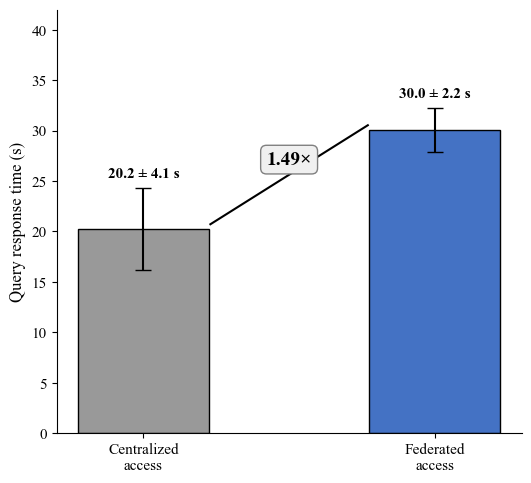

Figure 5 saved -> Results/  (ratio = 1.49x)


In [18]:
# --- Figure 5: Centralized vs. Federated access (paper style) ---
import os, numpy as np
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42; rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
GRAY, BLUE, RED = '#999999', '#4472C4', '#E04040'

means = [V['centralized']['mean'], V['federated']['mean']]
stds  = [V['centralized']['std'],  V['federated']['std']]

fig, ax = plt.subplots(1, 1, figsize=(6, 5.5), dpi=100)
x = np.arange(2)
ax.bar(x, means, yerr=stds, capsize=6, color=[GRAY, BLUE],
       edgecolor='black', linewidth=1.0, width=0.45)
ax.set_xticks(x); ax.set_xticklabels(['Centralized\naccess', 'Federated\naccess'], fontsize=12)
ax.set_ylabel('Query response time (s)', fontsize=12); ax.set_ylim(0, 42)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=11)
for xi, m, s in zip(x, means, stds):
    ax.text(xi, m + s + 0.8, f'{m:.1f} ± {s:.1f} s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ls_x, ls_y, le_x, le_y = 0.23, means[0] + 0.5, 0.77, means[1] + 0.5
ax.plot([ls_x, le_x], [ls_y, le_y], color='black', linewidth=1.5)
ratio = means[1] / means[0]
ax.text((ls_x + le_x) / 2, (ls_y + le_y) / 2 + 1.5, f'{ratio:.2f}×',
        fontsize=14, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='gray', linewidth=1.0))
os.makedirs('Results', exist_ok=True)
plt.savefig('Results/Figure 5. Centralized vs federated query time (v5.2.0).png',
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('Results/Figure 5. Centralized vs federated query time (v5.2.0).pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure 5 saved -> Results/  (ratio = {ratio:.2f}x)')

## Figure 2 — Vertical vs. Horizontal federation (Q2)

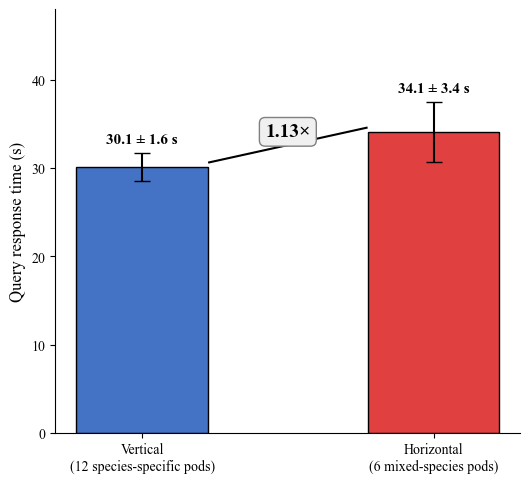

Figure 6 saved -> Results/  (ratio = 1.13x)


In [19]:
# --- Figure 6: Vertical vs. Horizontal federation (paper style) ---
v_mean, v_std = V['vertical']['mean'], V['vertical']['std']
h_mean, h_std = V['horizontal']['mean'], V['horizontal']['std']

fig, ax = plt.subplots(1, 1, figsize=(6, 5.5), dpi=100)
x = np.arange(2); means = [v_mean, h_mean]; stds = [v_std, h_std]
ax.bar(x, means, yerr=stds, capsize=6, color=[BLUE, RED],
       edgecolor='black', linewidth=1.0, width=0.45)
ax.set_xticks(x)
ax.set_xticklabels(['Vertical\n(12 species-specific pods)', 'Horizontal\n(6 mixed-species pods)'], fontsize=11)
ax.set_ylabel('Query response time (s)', fontsize=12); ax.set_ylim(0, 48)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)
for xi, m, s in zip(x, means, stds):
    ax.text(xi, m + s + 0.8, f'{m:.1f} ± {s:.1f} s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ls_x, ls_y, le_x, le_y = 0.23, v_mean + 0.5, 0.77, h_mean + 0.5
ax.plot([ls_x, le_x], [ls_y, le_y], color='black', linewidth=1.5)
ratio = h_mean / v_mean
ax.text((ls_x + le_x) / 2, (ls_y + le_y) / 2 + 1.5, f'{ratio:.2f}×',
        fontsize=14, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='gray', linewidth=1.0))
plt.savefig('Results/Figure 6. Vertical vs horizontal federation (v5.2.0).png',
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('Results/Figure 6. Vertical vs horizontal federation (v5.2.0).pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure 6 saved -> Results/  (ratio = {ratio:.2f}x)')

---
# Guidelines and Future Directions

## Data Access Model Selection Guidelines

Based on the experimental results obtained with Comunica v5.2.0 (Exp 1: centralized 20.21 ± 4.08 s vs. federated 30.03 ± 2.19 s; Exp 2 vertical 30.15 ± 1.57 s vs. Exp 3 horizontal 34.08 ± 3.40 s), the following guidelines are proposed for selecting an appropriate data access model:

| Criterion | Direct Sharing | Centralized | Decentralized (Solid Pods) |
|---|---|---|---|
| **Best for** | Small-scale, ad-hoc collaborations | Routine surveillance, dashboards | Multi-stakeholder networks prioritizing data sovereignty |
| **Data Scalability** | Low | Moderate | High |
| **Privacy/control** | Low (data leaves provider) | Moderate (anonymized, centralized) | High (data stays with provider) |
| **Performance** |  Not Applicable (manual) | High (local query) | Moderate (network + query overhead) |
| **Interoperability** | Low (CSV, ad-hoc schemas) | Moderate (standardized pipeline) | High (RDF + ontology + SPARQL) |
| **Setup complexity** | Low | Moderate | High |
| **Ease of Use** | Low | Moderate | Moderate |


### Direct Data Sharing

* **When to use:** small-scale, short-term, or early-stage projects where agility and minimal technical setup outweigh reusability.

* **Best practices:**
  * Limit to low-volume, bilateral exchanges.
  * Use clear data-sharing agreements.
  * Anonymise sensitive fields before sharing.
  * Document metadata alongside files (schema, version, date) to improve traceability.
  * Pair with simple dashboards or spreadsheets for quick visual analysis.

### Centralized Data Sharing

* **When to use:** coordinated surveillance workflows that require high performance, automation, and standardised pipelines.

* **Best practices:**
  * Agree on a predefined data format with all providers.
  * Develop and maintain ingestion scripts (R or Python) for consistency.
  * Apply anonymisation at ingestion for privacy protection.
  * Ensure the central server has strong governance, uptime monitoring, and version control.
  * Expose processed outputs to non-technical users via dashboards (e.g. Tableau, R Shiny).

### Federated Access using Solid Pods

* **When to use:** distributed networks where data providers need full ownership and selective access (for example, labs or farms unwilling to share raw data centrally).

* **Best practices:**
  * Align on a shared ontology (e.g. the Livestock Health Ontology) before implementation.
  * Provide lightweight training on SPARQL and RDF, or wrap queries behind user-friendly tools.
  * Configure Solid Pods with explicit ACL policies and embedded metadata (e.g. `schema:Dataset`).
  * Use a federated SPARQL engine such as Comunica (v5.2.0 or later) to query distributed pods in place, without moving data.
  * Apply query optimisation (pagination, filters pushed early, grouped source selection) to manage latency.

### Key Findings

1. **Vertical vs. horizontal federation.** Vertical federation (12 species-specific pods) and horizontal federation (6 mixed-species pods) return identical result sets (1,378 records: 569 cattle, 59 pig, 750 poultry). With Comunica v5.2.0 the two configurations differ by only 1.13× (30.15 s vs. 34.08 s), so the federation strategy can be chosen on governance and organisational grounds rather than performance.

2. **Centralized vs. federated trade-off.** Centralised access is faster (20.21 s) because the data are local, but federated access achieves competitive response times (30.03 s, 1.49× overhead) while keeping data inside each lab. The measured gap reflects the end-to-end cost of each paradigm (topology, engine, execution mode), not an engine-to-engine benchmark.



## Federated Learning (FL) Exploration

As a natural extension of the federated data-access model, we explored the feasibility of running federated learning (FL) directly inside Solid Pods. The initial goal was to train FL models within each Pod so that no raw data ever left the provider.

However, Solid Pods are designed as data-storage and access-control systems based on W3C standards; they are not compute environments. They cannot execute arbitrary code (for example, Python scripts or Docker containers) inside the Pod itself.

To work around this limitation, a hybrid architecture was adopted. A separate compute layer queries each Solid Pod via authenticated SPARQL requests, trains a local model on the retrieved data, and shares only aggregated model parameters — never the underlying records. This approach combines Solid's data sovereignty with FL's privacy-preserving computation.

Building on the ontology-driven data pipeline presented in this paper, a horizontal federated learning workflow for Bovine Respiratory Disease (BRD) prediction was developed using the same standardised, LHO-mapped RDF data stored in Solid Pods. Each participating laboratory trains a local model independently, and only model weight updates are aggregated centrally, preserving the data-ownership principles demonstrated in the federated access experiments. The source code will be made publicly available upon publication at: <https://github.com/Bovi-analytics/ontology_driven_horizontal_federated_learning_BRD>